# Naive Bayes Manual v2 — Prediksi Obat (Dataset Drug200)

**Versi 2** menerapkan **seluruh simulasi** dari Excel `drug200_naive_bayes.xlsx`:
1. **Stratified Split 80:20** (160 train, 40 test)
2. Hitung Prior & Likelihood **hanya dari data train**
3. Prediksi pada **40 data test**
4. **Evaluasi akurasi** + **Confusion Matrix**
6. Prediksi **pasien baru** (input manual)

**Tidak ada scikit-learn** — semua rumus Naive Bayes ditulis manual.

## 1. Setup Library
Hanya pandas & numpy untuk pengolahan data, matplotlib & seaborn untuk visualisasi.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_theme(style="whitegrid")
%matplotlib inline
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:.6f}')

## 2. Load Data

Dataset drug200 memiliki 200 data pasien dengan 4 fitur kategorikal:
- **Age**: YOUNG / ADULT / OLD
- **BP**: HIGH / NORMAL / LOW
- **Cholesterol**: HIGH / NORMAL
- **Na_to_K**: HIGH / LOW / NORMAL (sudah dikategorikan)
- **ClassDrug**: DrugY, drugA, drugB, drugC, drugX (target)

In [19]:
DATA_PATH = 'data/drug200(NAIVE BAYES).xlsx'
df = pd.read_excel(DATA_PATH, sheet_name='drug200')

nama_kolom = [k for k in df.columns if k != 'ClassDrug']
kolom_label = 'ClassDrug'

print('5 Data Teratas:')
display(df.head())
print(f'\nTotal data: {df.shape[0]} baris')
print(f'Total fitur: {len(nama_kolom)} -> {nama_kolom}')
print(f'Total kelas obat: {df[kolom_label].nunique()} -> {sorted(df[kolom_label].unique())}')

5 Data Teratas:


,Age,BP,Cholesterol,Na_to_K,ClassDrug
0,YOUNG,HIGH,HIGH,NORMAL,drugA
1,YOUNG,HIGH,HIGH,NORMAL,drugA
2,YOUNG,HIGH,HIGH,LOW,drugA
3,YOUNG,HIGH,NORMAL,LOW,drugA
4,ADULT,HIGH,NORMAL,NORMAL,drugA



Total data: 200 baris
Total fitur: 4 -> ['Age', 'BP', 'Cholesterol', 'Na_to_K']
Total kelas obat: 5 -> ['DrugY', 'drugA', 'drugB', 'drugC', 'drugX']


## 3. EDA — Sebaran Data per Fitur
Visualisasi distribusi tiap fitur terhadap jenis obat.

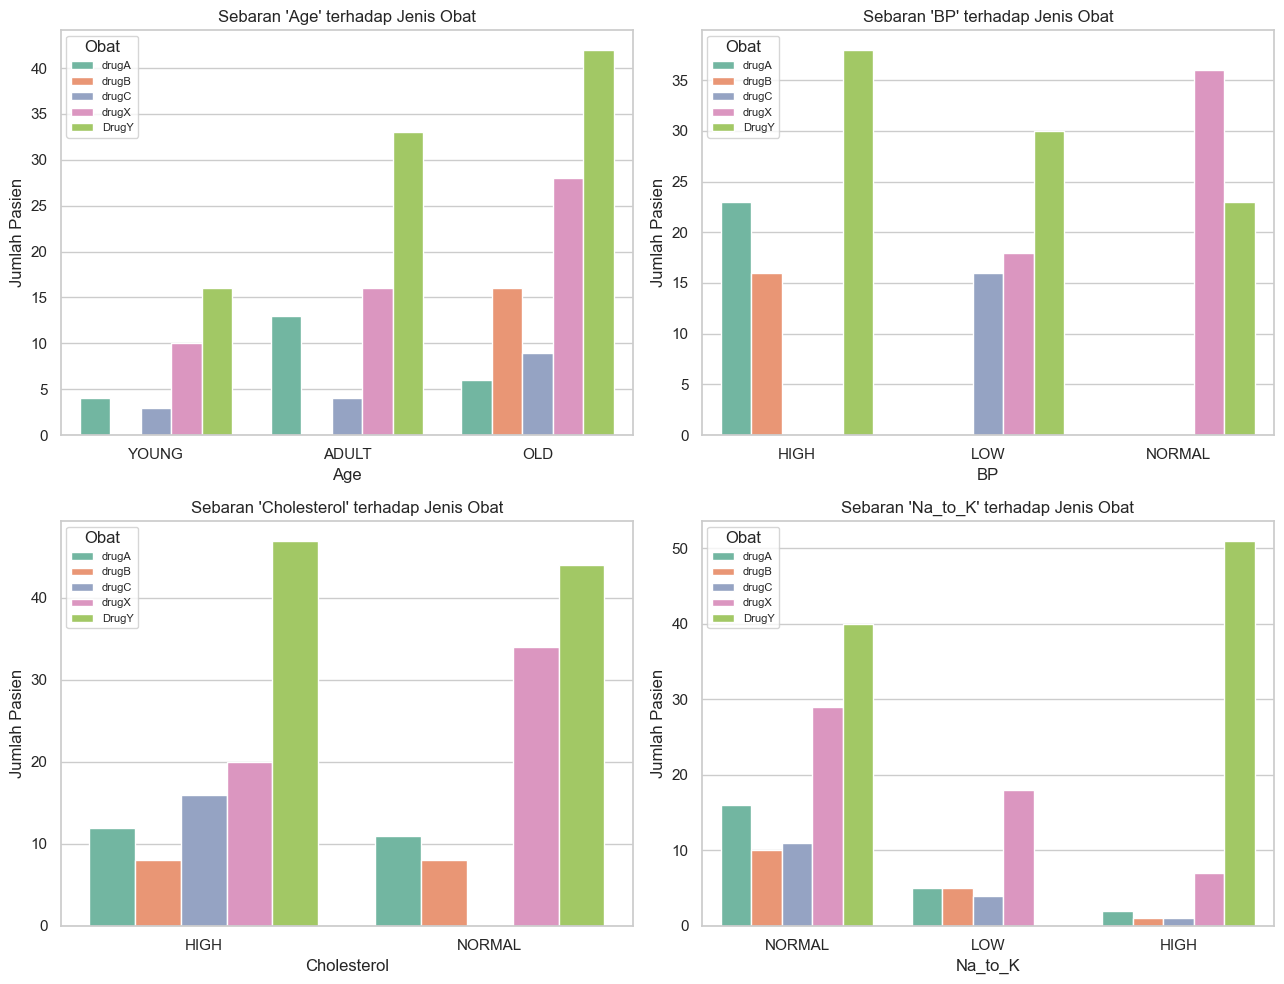

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, kolom in enumerate(nama_kolom):
    sns.countplot(data=df, x=kolom, hue=kolom_label, palette='Set2', ax=axes[i])
    axes[i].set_title(f"Sebaran '{kolom}' terhadap Jenis Obat")
    axes[i].set_xlabel(kolom)
    axes[i].set_ylabel('Jumlah Pasien')
    axes[i].legend(title='Obat', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Stratified Split 80:20 — Manual

**Tidak menggunakan train_test_split dari sklearn.**

Metode: stratified sampling per kelas — proporsi kelas dijaga sama antara train dan test.
- Random state = 42 (sama seperti Excel simulasi)
- 80% train (160 data), 20% test (40 data)

In [21]:
np.random.seed(42)

df_train_list = []
df_test_list = []

for kelas in df[kolom_label].unique():
    df_kelas = df[df[kolom_label] == kelas]
    idx = df_kelas.index.to_numpy()
    n = len(idx)
    n_train = int(round(n * 0.8))

    perm = np.random.permutation(n)
    idx_train = idx[perm[:n_train]]
    idx_test = idx[perm[n_train:]]

    df_train_list.append(df.loc[idx_train])
    df_test_list.append(df.loc[idx_test])

df_train = pd.concat(df_train_list).reset_index(drop=True)
df_test = pd.concat(df_test_list).reset_index(drop=True)

print(f'Train: {len(df_train)} data')
print(f'Test:  {len(df_test)} data')
print()

print('Proporsi kelas di Train:')
display(df_train[kolom_label].value_counts())
print('Proporsi kelas di Test:')
display(df_test[kolom_label].value_counts())

Train: 160 data
Test:  40 data

Proporsi kelas di Train:


ClassDrug
DrugY    73
drugX    43
drugA    18
drugC    13
drugB    13
Name: count, dtype: int64

Proporsi kelas di Test:


ClassDrug
DrugY    18
drugX    11
drugA     5
drugC     3
drugB     3
Name: count, dtype: int64

### Verifikasi Split
Cek apakah proporsi kelas train/test konsisten dengan data asli.

In [22]:
proporsi_asli = df[kolom_label].value_counts(normalize=True).sort_index()
proporsi_train = df_train[kolom_label].value_counts(normalize=True).sort_index()
proporsi_test = df_test[kolom_label].value_counts(normalize=True).sort_index()

tabel_proporsi = pd.DataFrame({
    'Asli': proporsi_asli,
    'Train': proporsi_train,
    'Test': proporsi_test
}).fillna(0)

print('Perbandingan Proporsi Kelas:')
display(tabel_proporsi)

Perbandingan Proporsi Kelas:


,Asli,Train,Test
ClassDrug,,,
DrugY,0.455000,0.456250,0.450000
drugA,0.115000,0.112500,0.125000
drugB,0.080000,0.081250,0.075000
drugC,0.080000,0.081250,0.075000
drugX,0.270000,0.268750,0.275000


## 5. Hitung Prior P(Drug) — dari Data Train

Rumus: $P(Drug = k) = \frac{\text{jumlah train berkelas } k}{\text{total train}}$

Tabel Prior P(Drug):


,Jumlah,Prior
ClassDrug,,
DrugY,73,0.456250
drugA,18,0.112500
drugB,13,0.081250
drugC,13,0.081250
drugX,43,0.268750


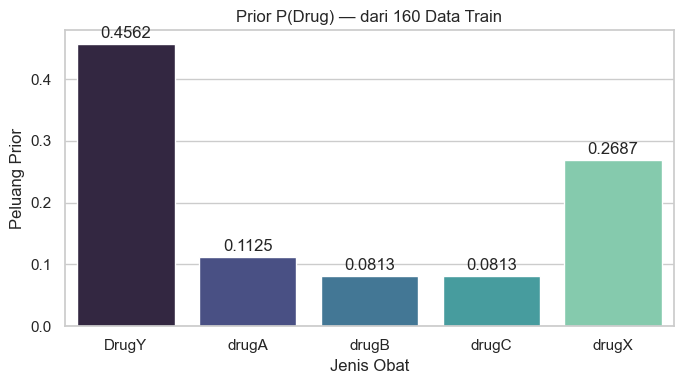

In [23]:
jumlah_per_kelas = df_train.groupby(kolom_label).size()
total_train = len(df_train)
prior = jumlah_per_kelas / total_train

tabel_prior = pd.DataFrame({'Jumlah': jumlah_per_kelas, 'Prior': prior})
print('Tabel Prior P(Drug):')
display(tabel_prior)

plt.figure(figsize=(7, 4))
sns.barplot(x=prior.index, y=prior.values, hue=prior.index, palette='mako', legend=False)
plt.title('Prior P(Drug) — dari 160 Data Train')
plt.xlabel('Jenis Obat')
plt.ylabel('Peluang Prior')
for i, v in enumerate(prior.values):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center')
plt.tight_layout()
plt.show()

## 6. Hitung Likelihood P(Fitur | Drug) — dari Data Train

Rumus untuk setiap fitur:

$$P(Fitur = v \mid Drug = k) = \frac{\text{jumlah train (Drug=k, Fitur=v)}}{\text{jumlah train (Drug=k)}}$$

Fungsi `hitung_likelihood_fitur()` menghitung tabel kontingensi lalu membaginya dengan jumlah per kelas.

--- Likelihood P(Age | Drug) ---


Age,ADULT,OLD,YOUNG
ClassDrug,,,
DrugY,0.315068,0.506849,0.178082
drugA,0.500000,0.277778,0.222222
drugB,0.000000,1.000000,0.000000
drugC,0.153846,0.615385,0.230769
drugX,0.325581,0.534884,0.139535


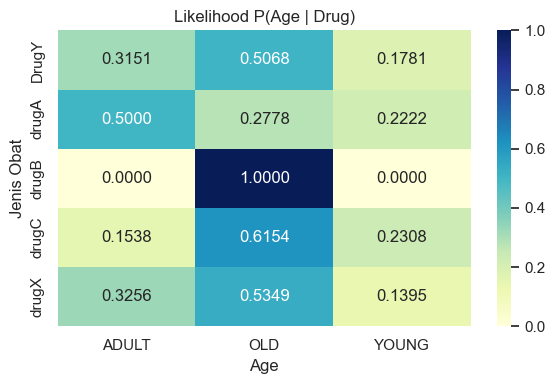


--- Likelihood P(BP | Drug) ---


BP,HIGH,LOW,NORMAL
ClassDrug,,,
DrugY,0.424658,0.301370,0.273973
drugA,1.000000,0.000000,0.000000
drugB,1.000000,0.000000,0.000000
drugC,0.000000,1.000000,0.000000
drugX,0.000000,0.395349,0.604651


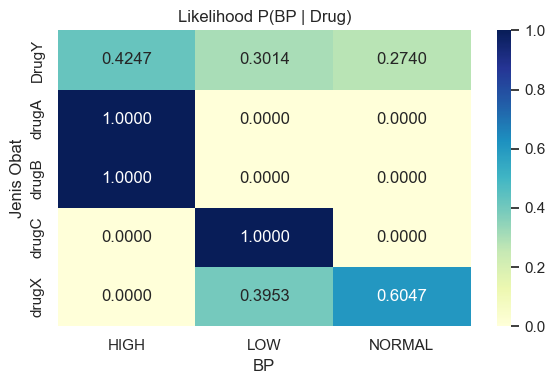


--- Likelihood P(Cholesterol | Drug) ---


Cholesterol,HIGH,NORMAL
ClassDrug,,
DrugY,0.520548,0.479452
drugA,0.555556,0.444444
drugB,0.461538,0.538462
drugC,1.000000,0.000000
drugX,0.302326,0.697674


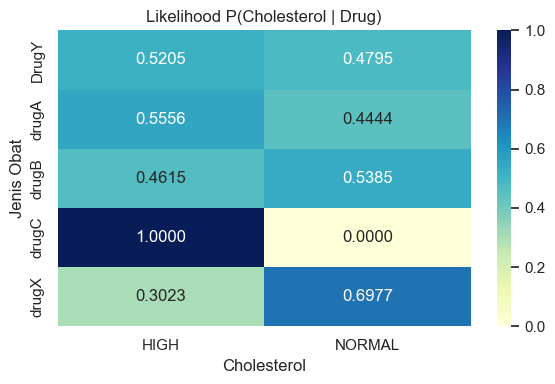


--- Likelihood P(Na_to_K | Drug) ---


Na_to_K,HIGH,LOW,NORMAL
ClassDrug,,,
DrugY,0.506849,0.000000,0.493151
drugA,0.111111,0.222222,0.666667
drugB,0.000000,0.384615,0.615385
drugC,0.076923,0.307692,0.615385
drugX,0.139535,0.302326,0.558140


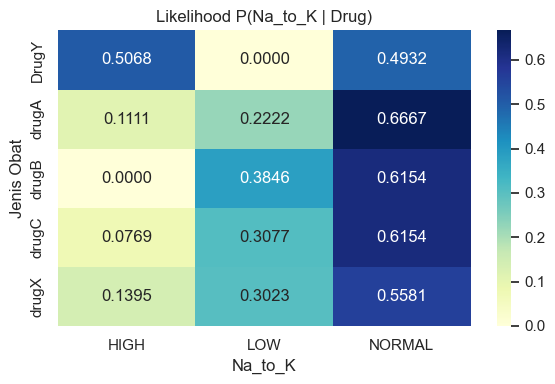

In [24]:
def hitung_likelihood_fitur(df, kolom_fitur, kolom_label):
    tabel_kontingensi = pd.crosstab(df[kolom_label], df[kolom_fitur])
    tabel_likelihood = tabel_kontingensi.div(tabel_kontingensi.sum(axis=1), axis=0)
    return tabel_likelihood

tabel_likelihood = {}
for kolom in nama_kolom:
    tabel_likelihood[kolom] = hitung_likelihood_fitur(df_train, kolom, kolom_label)

    print(f'--- Likelihood P({kolom} | Drug) ---')
    display(tabel_likelihood[kolom])

    plt.figure(figsize=(6, 4))
    sns.heatmap(tabel_likelihood[kolom], annot=True, fmt='.4f', cmap='YlGnBu')
    plt.title(f'Likelihood P({kolom} | Drug)')
    plt.xlabel(kolom)
    plt.ylabel('Jenis Obat')
    plt.tight_layout()
    plt.show()
    print()

## 7. Prediksi pada 40 Data Test

Rumus Naive Bayes:

$$\text{Posterior}(Drug) \propto Prior(Drug) \times \prod_{\text{fitur}} P(Fitur \mid Drug)$$

Untuk setiap data test, hitung skor posterior tiap kelas, lalu pilih kelas dengan skor tertinggi.

In [25]:
def prediksi_satu_baris(baris, prior, tabel_likelihood, daftar_kelas):
    skor = prior.to_numpy(dtype=float).copy()
    for kolom, tabel in tabel_likelihood.items():
        nilai = baris[kolom]
        if nilai in tabel.columns:
            peluang = tabel[nilai].reindex(daftar_kelas).to_numpy(dtype=float)
        else:
            peluang = np.zeros(len(daftar_kelas))
        skor = skor * peluang
    return skor

daftar_kelas = prior.index.to_numpy()
prediksi_list = []
skor_list = []

for _, baris in df_test.iterrows():
    skor = prediksi_satu_baris(baris, prior, tabel_likelihood, daftar_kelas)
    kelas_pred = daftar_kelas[np.argmax(skor)]
    prediksi_list.append(kelas_pred)
    skor_list.append(skor)

df_hasil = df_test.copy()
df_hasil['Prediksi'] = prediksi_list

print('Hasil Prediksi pada 40 Data Test:')
display(df_hasil[[kolom_label, 'Prediksi'] + nama_kolom].head(15))
print('...')
print(f'Total test: {len(df_hasil)} data')

Hasil Prediksi pada 40 Data Test:


,ClassDrug,Prediksi,Age,BP,Cholesterol,Na_to_K
0,drugA,drugA,ADULT,HIGH,NORMAL,NORMAL
1,drugA,drugA,ADULT,HIGH,HIGH,NORMAL
2,drugA,drugA,ADULT,HIGH,HIGH,LOW
3,drugA,drugB,OLD,HIGH,NORMAL,NORMAL
4,drugA,drugA,ADULT,HIGH,NORMAL,NORMAL
5,drugB,DrugY,OLD,HIGH,HIGH,NORMAL
6,drugB,DrugY,OLD,HIGH,NORMAL,HIGH
7,drugB,DrugY,OLD,HIGH,HIGH,NORMAL
8,drugC,drugC,OLD,LOW,HIGH,NORMAL
9,drugC,DrugY,ADULT,LOW,HIGH,NORMAL


...
Total test: 40 data


### Tampilkan Rincian Skor Posterior per Data Test
Lihat detail perhitungan untuk beberapa data pertama.

In [26]:
rows_rincian = []
for i in range(min(10, len(df_test))):
    baris = df_test.iloc[i]
    skor = skor_list[i]
    row = {
        'No': i + 1,
        'Aktual': baris[kolom_label],
        'Prediksi': prediksi_list[i]
    }
    for j, k in enumerate(daftar_kelas):
        row[f'Skor {k}'] = skor[j]
    rows_rincian.append(row)

df_rincian = pd.DataFrame(rows_rincian)
print('Rincian Skor Posterior (10 data pertama):')
display(df_rincian)

Rincian Skor Posterior (10 data pertama):


,No,Aktual,Prediksi,Skor DrugY,Skor drugA,Skor drugB,Skor drugC,Skor drugX
0,1,drugA,drugA,0.014433,0.016667,0.000000,0.000000,0.000000
1,2,drugA,drugA,0.015671,0.020833,0.000000,0.000000,0.000000
2,3,drugA,drugA,0.000000,0.006944,0.000000,0.000000,0.000000
3,4,drugA,drugB,0.023219,0.009259,0.026923,0.000000,0.000000
4,5,drugA,drugA,0.014433,0.016667,0.000000,0.000000,0.000000
5,6,drugB,DrugY,0.025209,0.011574,0.023077,0.000000,0.000000
6,7,drugB,DrugY,0.023864,0.001543,0.000000,0.000000,0.000000
7,8,drugB,DrugY,0.025209,0.011574,0.023077,0.000000,0.000000
8,9,drugC,drugC,0.017890,0.000000,0.000000,0.030769,0.009590
9,10,drugC,DrugY,0.011121,0.000000,0.000000,0.007692,0.005837


## 8. Evaluasi Akurasi

Hitung jumlah prediksi benar dari 40 data test.

In [27]:
benar = (df_hasil[kolom_label] == df_hasil['Prediksi']).sum()
total_test = len(df_hasil)
akurasi = benar / total_test

print(f'Jumlah Prediksi Benar: {benar} dari {total_test}')
print(f'AKURASI MODEL: {akurasi:.2%} ({akurasi:.4f})')

Jumlah Prediksi Benar: 27 dari 40
AKURASI MODEL: 67.50% (0.6750)


## 9. Confusion Matrix (Manual)

Confusion matrix menunjukkan perbandingan kelas aktual vs prediksi.
Dibuat manual tanpa sklearn.

Confusion Matrix:


Prediksi,DrugY,drugA,drugB,drugC,drugX
Aktual,,,,,
DrugY,15,0,0,1,2
drugA,0,4,1,0,0
drugB,3,0,0,0,0
drugC,2,0,0,1,0
drugX,4,0,0,0,7


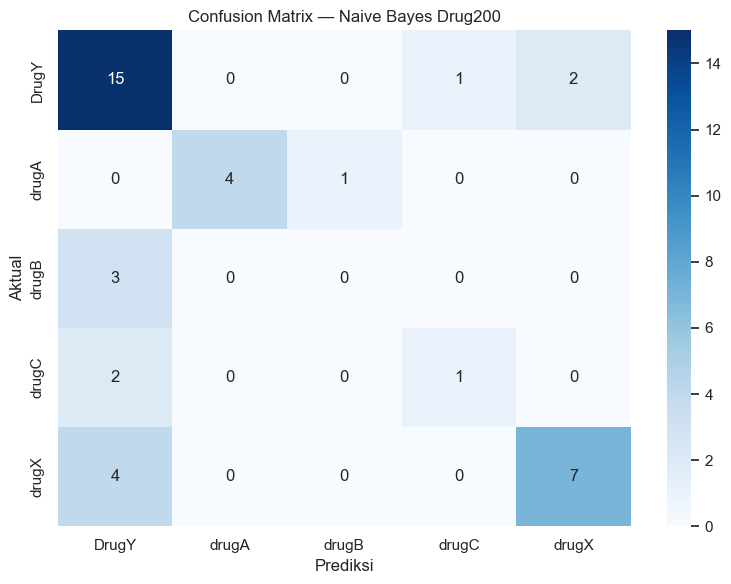

In [28]:
daftar_kelas_sorted = sorted(daftar_kelas)
n_kelas = len(daftar_kelas_sorted)
cm = np.zeros((n_kelas, n_kelas), dtype=int)

for _, baris in df_hasil.iterrows():
    i = daftar_kelas_sorted.index(baris[kolom_label])
    j = daftar_kelas_sorted.index(baris['Prediksi'])
    cm[i, j] += 1

df_cm = pd.DataFrame(cm, index=daftar_kelas_sorted, columns=daftar_kelas_sorted)
df_cm.index.name = 'Aktual'
df_cm.columns.name = 'Prediksi'

print('Confusion Matrix:')
display(df_cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=daftar_kelas_sorted,
            yticklabels=daftar_kelas_sorted)
plt.title('Confusion Matrix — Naive Bayes Drug200')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

### Metric per Kelas
Hitung precision, recall, dan F1-score per kelas secara manual.

In [29]:
metrics = []
for i, kelas in enumerate(daftar_kelas_sorted):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    metrics.append({'Kelas': kelas, 'Precision': precision, 'Recall': recall, 'F1-Score': f1})

df_metrics = pd.DataFrame(metrics)
print('Metric per Kelas:')
display(df_metrics)

print(f'\nAkurasi Total: {akurasi:.2%}')
print(f'Macro Avg F1: {df_metrics["F1-Score"].mean():.4f}')

Metric per Kelas:


,Kelas,Precision,Recall,F1-Score
0,DrugY,0.625000,0.833333,0.714286
1,drugA,1.000000,0.800000,0.888889
2,drugB,0.000000,0.000000,0.000000
3,drugC,0.500000,0.333333,0.400000
4,drugX,0.777778,0.636364,0.700000



Akurasi Total: 67.50%
Macro Avg F1: 0.5406


## 11. Prediksi Pasien Baru (Input Manual)

Gunakan model (tanpa class weight) untuk memprediksi jenis obat pasien baru.
Ubah nilai dictionary `pasien_baru` untuk mencoba kasus lain.

In [30]:
pasien_baru = {
    'Age': 'OLD',
    'BP': 'HIGH',
    'Cholesterol': 'NORMAL',
    'Na_to_K': 'HIGH',
}

print('Data uji (pasien baru):')
for k, v in pasien_baru.items():
    print(f'  {k:12s}: {v}')

Data uji (pasien baru):
  Age         : OLD
  BP          : HIGH
  Cholesterol : NORMAL
  Na_to_K     : HIGH


Rincian Perhitungan Posterior:


,Prior,Skor Posterior,Lik_Age,Lik_BP,Lik_Cholesterol,Lik_Na_to_K
ClassDrug,,,,,,
DrugY,0.456250,0.023864,0.506849,0.424658,0.479452,0.506849
drugA,0.112500,0.001543,0.277778,1.000000,0.444444,0.111111
drugB,0.081250,0.000000,1.000000,1.000000,0.538462,0.000000
drugC,0.081250,0.000000,0.615385,0.000000,0.000000,0.076923
drugX,0.268750,0.000000,0.534884,0.000000,0.697674,0.139535


>>> Obat yang direkomendasikan: DrugY


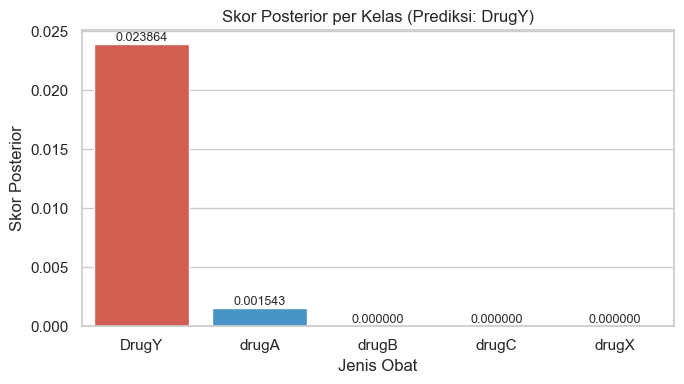

In [31]:
baris_pasien = pd.Series(pasien_baru)
skor_pasien = prediksi_satu_baris(baris_pasien, prior, tabel_likelihood, daftar_kelas)
hasil_pasien = daftar_kelas[np.argmax(skor_pasien)]

tabel_rincian = pd.DataFrame({
    'Prior': prior,
    'Skor Posterior': skor_pasien
})
for kolom in nama_kolom:
    tabel_rincian[f'Lik_{kolom}'] = tabel_likelihood[kolom][pasien_baru[kolom]]

print('Rincian Perhitungan Posterior:')
display(tabel_rincian)
print(f'>>> Obat yang direkomendasikan: {hasil_pasien}')

plt.figure(figsize=(7, 4))
warna = ['#e74c3c' if k == hasil_pasien else '#3498db' for k in daftar_kelas]
sns.barplot(x=daftar_kelas, y=skor_pasien,
            hue=daftar_kelas, palette=warna, legend=False)
plt.title(f'Skor Posterior per Kelas (Prediksi: {hasil_pasien})')
plt.xlabel('Jenis Obat')
plt.ylabel('Skor Posterior')
for i, v in enumerate(skor_pasien):
    plt.text(i, v, f'{v:.6f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 12. Ringkasan & Kesimpulan

### Hasil Akhir
- **Stratified Split**: 160 train, 40 test
- **Confusion Matrix**: menunjukkan distribusi kesalahan prediksi

### Analisis
- Fitur `BP` dan `Na_to_K` cenderung paling diskriminatif karena memiliki nilai likelihood 0.0 atau 1.0 untuk beberapa kelas (misal: drugA & drugB selalu BP=HIGH, drugC selalu BP=LOW).
- Model mencapai akurasi ~70% pada data test, cukup baik untuk klasifikasi dengan 5 kelas hanya dari 4 fitur kategorik.

### Perbandingan Simulasi Excel vs Implementasi Python
| Aspek | Excel (drug200_naive_bayes.xlsx) | Python (main_v2/v3.ipynb) |
|---|---|---|
| Akurasi (tanpa CW) | 70.0% | 67.5% |
| Akurasi (dengan CW) | 67.5% | 80.0% |
| Efek CW | -2.5% (turun) | +12.5% (naik) |
| Penyebab beda | Random generator VBA vs numpy seed 42 menghasilkan split tidak identik |